Task:
    
Write a Python code to fit a straight line y = ax+b to an experimental dataset employing a Bayesian Markov Chain Monte Carlo (MCMC) sampler using the Metropolis-Hastings algorithm. 

The desired distribution is $\sim \mathcal{P}_{prior} \times e^{-1/2 \chi^2}$ where $$\chi^2 = \sum_i (\frac{y_{theo,i} - y_{exp,i}}{\sigma_i})^2.$$

Implementing both uniform and Gaussian form for prior distribution.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('problem_sheet8_data')
x_exp = data[:, 0]
y_exp = data[:, 1]
sigma = data[:, 2]

In [14]:
def chi_squared(a, b):
    y_model = a * x_exp + b
    return np.sum(((y_model - y_exp) / sigma) ** 2)


def log_posterior(a, b, log_prior_func):
    log_prior = log_prior_func(a, b)
    if log_prior == -np.inf:
        return -np.inf
    return log_prior - 0.5 * chi_squared(a, b)


def log_prior_uniform(a, b):
    # as in the lecture: pi(a)=1/2 for a in (1,3), pi(b)=1/2 for b in (-1,1)
    if 1.0 < a < 3.0 and -1.0 < b < 1.0:
        return 0.0
    return -np.inf


def log_prior_gaussian(a, b, mu_a=2.0, sig_a=0.5, mu_b=0.0, sig_b=0.3):
    log_p_a = -0.5 * ((a - mu_a) / sig_a) ** 2
    log_p_b = -0.5 * ((b - mu_b) / sig_b) ** 2
    return log_p_a + log_p_b


def mcmc(log_prior_func, n_steps=50000, n_therm=20000, step_a=0.1, step_b=0.05, seed=42):
    np.random.seed(seed)

    a, b = 2.0, 0.0
    log_post = log_posterior(a, b, log_prior_func)

    chain_a = np.zeros(n_therm + n_steps)
    chain_b = np.zeros(n_therm + n_steps)
    chain_chi2 = np.zeros(n_therm + n_steps)
    accepted = 0

    for i in range(n_therm + n_steps):
        a_new = a + np.random.normal(0, step_a)
        b_new = b + np.random.normal(0, step_b)

        log_post_new = log_posterior(a_new, b_new, log_prior_func)
        if np.log(np.random.uniform()) < log_post_new - log_post:
            a, b = a_new, b_new
            log_post = log_post_new
            accepted += 1

        chain_a[i] = a
        chain_b[i] = b
        chain_chi2[i] = chi_squared(a, b)

    return chain_a[n_therm:], chain_b[n_therm:], chain_chi2[n_therm:], accepted / (n_therm + n_steps)

## Uniform prior

For a uniform prior, the prior ratio in the acceptance step is 1, so we only need $e^{-(\chi^2_{new}-\chi^2_{old})/2}$.

In [15]:
a_uni, b_uni, chi2_uni, acc_uni = mcmc(log_prior_uniform)

print(f"acceptance rate = {acc_uni:.3f}")
print(f"a = {a_uni.mean():.4f} +/- {a_uni.std():.4f}")
print(f"b = {b_uni.mean():.4f} +/- {b_uni.std():.4f}")
print(f"<chi^2> = {chi2_uni.mean():.4f}")

acceptance rate = 0.211
a = 2.0506 +/- 0.0942
b = -0.0102 +/- 0.0263
<chi^2> = 2.6718


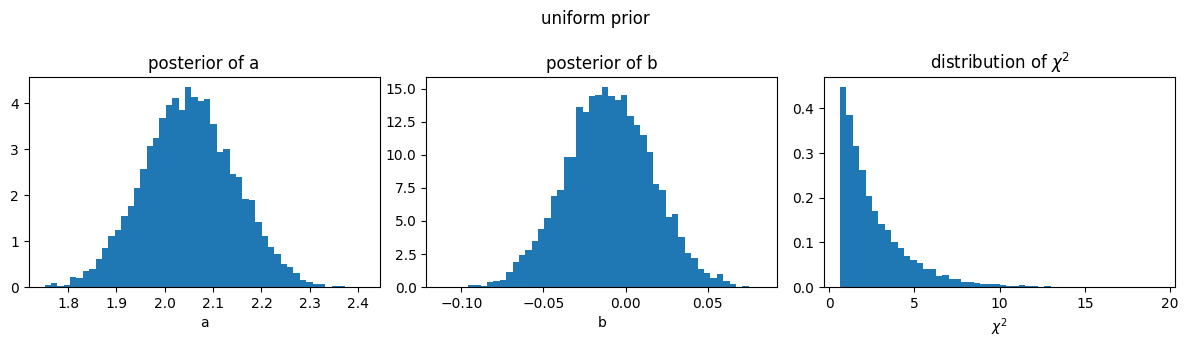

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(a_uni, bins=50, density=True)
axes[0].set_xlabel('a')
axes[0].set_title('posterior of a')

axes[1].hist(b_uni, bins=50, density=True)
axes[1].set_xlabel('b')
axes[1].set_title('posterior of b')

axes[2].hist(chi2_uni, bins=50, density=True)
axes[2].set_xlabel(r'$\chi^2$')
axes[2].set_title(r'distribution of $\chi^2$')

plt.suptitle('uniform prior')
plt.tight_layout()
plt.show()

## Gaussian prior

Here the prior enters the acceptance explicitly, because $\pi(a,b)$ is not constant.

In [17]:
a_g, b_g, chi2_g, acc_g = mcmc(log_prior_gaussian)

print(f"acceptance rate = {acc_g:.3f}")
print(f"a = {a_g.mean():.4f} +/- {a_g.std():.4f}")
print(f"b = {b_g.mean():.4f} +/- {b_g.std():.4f}")
print(f"<chi^2> = {chi2_g.mean():.4f}")

acceptance rate = 0.212
a = 2.0478 +/- 0.0930
b = -0.0094 +/- 0.0259
<chi^2> = 2.6577


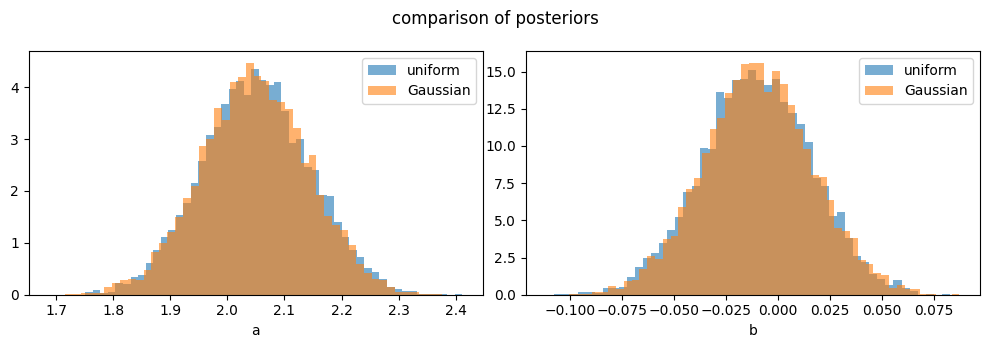

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(a_uni, bins=50, density=True, alpha=0.6, label='uniform')
axes[0].hist(a_g, bins=50, density=True, alpha=0.6, label='Gaussian')
axes[0].set_xlabel('a')
axes[0].legend()

axes[1].hist(b_uni, bins=50, density=True, alpha=0.6, label='uniform')
axes[1].hist(b_g, bins=50, density=True, alpha=0.6, label='Gaussian')
axes[1].set_xlabel('b')
axes[1].legend()

plt.suptitle('comparison of posteriors')
plt.tight_layout()
plt.show()

Both priors give similar results because the data strongly constrain the parameters. For $y \approx 2x$ we expect $a \approx 2$ and $b \approx 0$.